# Tutorial 6 · Densities & Gaussians — Part B

**~40 minutes · after the worksheet**

Connect density, area, sampling, transformations, and covariance geometry.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Density is area, not height


area: 0.14999999999999997


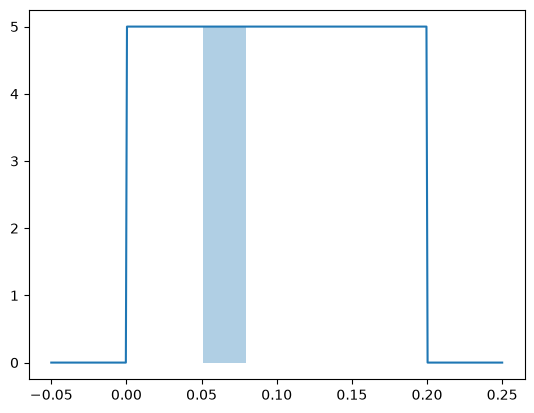

In [1]:
#| fig-alt: 'Uniform probability density on an interval, with a smaller subinterval shaded to represent its probability mass.'
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-.05, .25, 400)
pdf = stats.uniform(0, .2).pdf(x)
plt.plot(x, pdf); plt.fill_between(x, 0, pdf, where=(x>.05)&(x<.08), alpha=.35)
print("area:", stats.uniform(0, .2).cdf(.08)-stats.uniform(0, .2).cdf(.05))


## 2 · Transform samples


In [2]:
rng = np.random.default_rng(6)
X = rng.normal(2, 3, 100_000); Y = 3*X - 1
print("X mean/var", X.mean(), X.var())
print("Y mean/var", Y.mean(), Y.var())


X mean/var 1.997233026050611 8.997535310393223
Y mean/var 4.991699078151833 80.97781779353902


## 3 · A covariance ellipse from eigenvectors


[1. 7.] [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


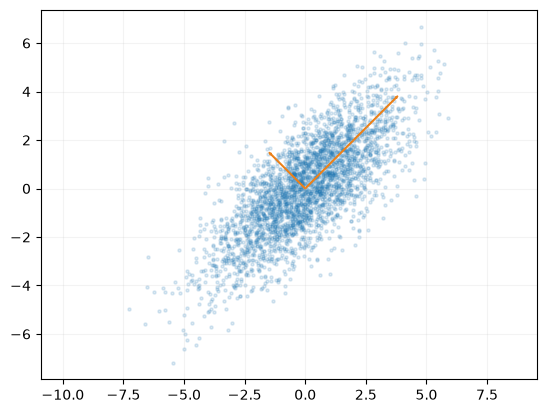

In [3]:
#| fig-alt: 'Correlated bivariate Gaussian sample cloud with covariance eigenvectors drawn along its short and long axes.'
Sigma = np.array([[4., 3.], [3., 4.]])
Z = rng.multivariate_normal([0, 0], Sigma, 3000)
values, vectors = np.linalg.eigh(Sigma)
plt.scatter(*Z.T, s=5, alpha=.15)
for value, vector in zip(values, vectors.T):
    plt.arrow(0, 0, *(2*np.sqrt(value)*vector), width=.025, color="#EB811B")
plt.axis("equal"); plt.grid(alpha=.15)
print(values, vectors)


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
